In [ ]:
pip install gurobipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 37.4 MB/s eta 0:00:00


In [ ]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# Parameters
n = 11  # Number of locations (0 = warehouse, 1-10 = delivery stops)
K = 4   # Number of products

np.random.seed(6)

# Base travel distances (km)
base_travel_distance = {
    (0, 1): 55, (0, 2): 50, (0, 3): 45, (0, 4): 40, (0, 5): 35,
    (0, 6): 60, (0, 7): 65, (0, 8): 70, (0, 9): 75, (0, 10): 80,
    (1, 0): 55, (1, 2): 30, (1, 3): 40, (1, 4): 50, (1, 5): 60, (1, 6): 65,
    (1, 7): 70, (1, 8): 75, (1, 9): 80, (1, 10): 85,
    (2, 0): 50, (2, 1): 30, (2, 3): 35, (2, 4): 45, (2, 5): 55, (2, 6): 50,
    (2, 7): 55, (2, 8): 60, (2, 9): 65, (2, 10): 70,
    (3, 0): 45, (3, 1): 40, (3, 2): 35, (3, 4): 25, (3, 5): 30, (3, 6): 40,
    (3, 7): 45, (3, 8): 50, (3, 9): 55, (3, 10): 60,
    (4, 0): 40, (4, 1): 50, (4, 2): 45, (4, 3): 25, (4, 5): 20, (4, 6): 35,
    (4, 7): 40, (4, 8): 45, (4, 9): 50, (4, 10): 55,
    (5, 0): 35, (5, 1): 60, (5, 2): 55, (5, 3): 30, (5, 4): 20, (5, 6): 25,
    (5, 7): 30, (5, 8): 35, (5, 9): 40, (5, 10): 45,
    (6, 0): 60, (6, 1): 65, (6, 2): 50, (6, 3): 40, (6, 4): 35, (6, 5): 25,
    (6, 7): 20, (6, 8): 25, (6, 9): 30, (6, 10): 35,
    (7, 0): 65, (7, 1): 70, (7, 2): 55, (7, 3): 45, (7, 4): 40, (7, 5): 30,
    (7, 6): 20, (7, 8): 15, (7, 9): 20, (7, 10): 25,
    (8, 0): 70, (8, 1): 75, (8, 2): 60, (8, 3): 50, (8, 4): 45, (8, 5): 35,
    (8, 6): 25, (8, 7): 15, (8, 9): 10, (8, 10): 15,
    (9, 0): 75, (9, 1): 80, (9, 2): 65, (9, 3): 55, (9, 4): 50, (9, 5): 40,
    (9, 6): 30, (9, 7): 20, (9, 8): 10, (9, 10): 10,
    (10, 0): 80, (10, 1): 85, (10, 2): 70, (10, 3): 60, (10, 4): 55, (10, 5): 45,
    (10, 6): 35, (10, 7): 25, (10, 8): 15, (10, 9): 10,
}

# Travel times with noise
base_travel_time = {k: v / 30 for k, v in base_travel_distance.items()}
travel_times = {(i, j): base_travel_time.get((i, j), 0) + np.random.uniform(-0.5, 0.5)
                for i in range(n) for j in range(n) if i != j}
delays = [np.random.uniform(0.1, 0.2) if np.random.rand() < 0.2 else 0 for _ in range(n)]

# Temperature control
required_temp = [5, 13, 10, 8]
initial_temp = required_temp[:]
min_temp = [2, 10, 7, 5]
max_temp = [8, 16, 13, 11]
temperature_changes = np.random.uniform(-1, 1, (n, K))
beta = 0.2
M = 50

# Adaptive Planning Loop
visited = [0]
unvisited = list(range(1, n))
current_node = 0
current_temp = initial_temp[:]
route = []
total_obj = 0

while unvisited:
    model = gp.Model("AdaptiveStep")
    model.setParam("OutputFlag", 0)

    x = model.addVars(unvisited, vtype=GRB.BINARY, name="x")
    model.addConstr(gp.quicksum(x[j] for j in unvisited) == 1)

    temp_next = model.addVars(unvisited, K, vtype=GRB.CONTINUOUS)
    abs_dev = model.addVars(unvisited, K, vtype=GRB.CONTINUOUS)
    slack = model.addVars(unvisited, K, vtype=GRB.CONTINUOUS)

    for j in unvisited:
        for k in range(K):
            ambient = temperature_changes[j][k]
            correction = beta * (required_temp[k] - current_temp[k])
            expected_temp = current_temp[k] + ambient + correction
            model.addConstr(temp_next[j, k] >= expected_temp - slack[j, k] - M * (1 - x[j]))
            model.addConstr(temp_next[j, k] <= expected_temp + slack[j, k] + M * (1 - x[j]))
            model.addConstr(temp_next[j, k] >= min_temp[k])
            model.addConstr(temp_next[j, k] <= max_temp[k])
            model.addConstr(abs_dev[j, k] >= temp_next[j, k] - required_temp[k])
            model.addConstr(abs_dev[j, k] >= required_temp[k] - temp_next[j, k])

    travel_cost = gp.quicksum((travel_times[current_node, j] + delays[current_node]) * x[j] for j in unvisited)
    penalty = gp.quicksum(0.05 * abs_dev[j, k] + 0.1 * slack[j, k] for j in unvisited for k in range(K))

    model.setObjective(travel_cost + penalty, GRB.MINIMIZE)
    model.optimize()

    for j in unvisited:
        if x[j].X > 0.5:
            print(f"\n--- Traveling from {current_node} to {j} ---")
            print(f"Delay at {current_node}: {delays[current_node]:.2f} hours")
            for k in range(K):
                ambient = temperature_changes[j][k]
                ideal = required_temp[k]
                incoming_temp = current_temp[k]
                correction = beta * (ideal - incoming_temp)
                expected = incoming_temp + ambient + correction
                final_temp = temp_next[j, k].X
                deviation = abs(final_temp - ideal)

                print(f"Product {k}:")
                print(f"  Incoming Temp      : {incoming_temp:.2f} °C")
                print(f"  Ambient Shift      : {ambient:.2f} °C")
                print(f"  Correction Applied : {correction:.2f} °C")
                print(f"  Expected Temp      : {expected:.2f} °C")
                print(f"  Final Temp         : {final_temp:.2f} °C")
                print(f"  Deviation from Ideal ({ideal}°C): {deviation:.2f} °C")

            route.append((current_node, j))
            total_obj += model.objVal
            current_temp = [temp_next[j, k].X for k in range(K)]
            current_node = j
            visited.append(j)
            unvisited.remove(j)
            break

# Return to warehouse
route.append((current_node, 0))
total_obj += travel_times.get((current_node, 0), 0) + delays[current_node]

# Final Output
print("\n✅ Adaptive Route:")
for i, j in route:
    print(f"Travel from {i} to {j}")
print(f"\n🎯 Total Objective (with adaptive re-optimization): {total_obj:.2f}")



--- Traveling from 0 to 5 ---
Delay at 0: 0.00 hours
Product 0:
  Incoming Temp      : 5.00 °C
  Ambient Shift      : -0.55 °C
  Correction Applied : 0.00 °C
  Expected Temp      : 4.45 °C
  Final Temp         : 4.45 °C
  Deviation from Ideal (5°C): 0.55 °C
Product 1:
  Incoming Temp      : 13.00 °C
  Ambient Shift      : 0.96 °C
  Correction Applied : 0.00 °C
  Expected Temp      : 13.96 °C
  Final Temp         : 13.96 °C
  Deviation from Ideal (13°C): 0.96 °C
Product 2:
  Incoming Temp      : 10.00 °C
  Ambient Shift      : 0.17 °C
  Correction Applied : 0.00 °C
  Expected Temp      : 10.17 °C
  Final Temp         : 10.17 °C
  Deviation from Ideal (10°C): 0.17 °C
Product 3:
  Incoming Temp      : 8.00 °C
  Ambient Shift      : 0.96 °C
  Correction Applied : 0.00 °C
  Expected Temp      : 8.96 °C
  Final Temp         : 8.96 °C
  Deviation from Ideal (8°C): 0.96 °C

--- Traveling from 5 to 4 ---
Delay at 5: 0.00 hours
Product 0:
  Incoming Temp      : 4.45 °C
  Ambient Shift      : -0

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# Parameters
n = 11  # Number of locations (0 = warehouse, 1-10 = delivery stops)
K = 4   # Number of products (Apples, Bananas, Tomatoes, xyz)

np.random.seed(6)

# Base travel distances (km)
base_travel_distance = {
    (0, 1): 55, (0, 2): 50, (0, 3): 45, (0, 4): 40, (0, 5): 35,
    (0, 6): 60, (0, 7): 65, (0, 8): 70, (0, 9): 75, (0, 10): 80,
    (1, 0): 55, (1, 2): 30, (1, 3): 40, (1, 4): 50, (1, 5): 60, (1, 6): 65,
    (1, 7): 70, (1, 8): 75, (1, 9): 80, (1, 10): 85,
    (2, 0): 50, (2, 1): 30, (2, 3): 35, (2, 4): 45, (2, 5): 55, (2, 6): 50,
    (2, 7): 55, (2, 8): 60, (2, 9): 65, (2, 10): 70,
    (3, 0): 45, (3, 1): 40, (3, 2): 35, (3, 4): 25, (3, 5): 30, (3, 6): 40,
    (3, 7): 45, (3, 8): 50, (3, 9): 55, (3, 10): 60,
    (4, 0): 40, (4, 1): 50, (4, 2): 45, (4, 3): 25, (4, 5): 20, (4, 6): 35,
    (4, 7): 40, (4, 8): 45, (4, 9): 50, (4, 10): 55,
    (5, 0): 35, (5, 1): 60, (5, 2): 55, (5, 3): 30, (5, 4): 20, (5, 6): 25,
    (5, 7): 30, (5, 8): 35, (5, 9): 40, (5, 10): 45,
    (6, 0): 60, (6, 1): 65, (6, 2): 50, (6, 3): 40, (6, 4): 35, (6, 5): 25,
    (6, 7): 20, (6, 8): 25, (6, 9): 30, (6, 10): 35,
    (7, 0): 65, (7, 1): 70, (7, 2): 55, (7, 3): 45, (7, 4): 40, (7, 5): 30,
    (7, 6): 20, (7, 8): 15, (7, 9): 20, (7, 10): 25,
    (8, 0): 70, (8, 1): 75, (8, 2): 60, (8, 3): 50, (8, 4): 45, (8, 5): 35,
    (8, 6): 25, (8, 7): 15, (8, 9): 10, (8, 10): 15,
    (9, 0): 75, (9, 1): 80, (9, 2): 65, (9, 3): 55, (9, 4): 50, (9, 5): 40,
    (9, 6): 30, (9, 7): 20, (9, 8): 10, (9, 10): 10,
    (10, 0): 80, (10, 1): 85, (10, 2): 70, (10, 3): 60, (10, 4): 55, (10, 5): 45,
    (10, 6): 35, (10, 7): 25, (10, 8): 15, (10, 9): 10,
}

base_travel_time = {k: v / 30 for k, v in base_travel_distance.items()}  # time in hours at 30 km/h

travel_times = {(i, j): base_travel_time.get((i, j), 0) + np.random.uniform(-0.5, 0.5)
                for i in range(n) for j in range(n) if i != j}

delays = [np.random.uniform(0.1, 0.2) if np.random.rand() < 0.1 else 0 for _ in range(n)]

# Temperature requirements and initial temperatures
required_temperature = [5, 13, 10, 8]  # Ideal temperatures (°C)
initial_temperature = [5, 13, 10, 8]   # Starting at warehouse (°C)

# Random temperature shifts at each stop (ambient exposure)
temperature_changes = np.random.uniform(-1, 1, (n, K))

# Truck capabilities (realistic limits)
min_temp = [2, 10, 7, 5]  # Lower bound (°C)
max_temp = [8, 16, 13, 11]  # Upper bound (°C)

# Create model
model = gp.Model('Adaptive_Perishable_Transportation')

# Decision Variables
x = model.addVars(n, n, vtype=GRB.BINARY, name="x")
u = model.addVars(n, lb=0, ub=n-1, vtype=GRB.CONTINUOUS)
temp = model.addVars(n, K, vtype=GRB.CONTINUOUS, name="temp")
abs_deviation = model.addVars(n, K, vtype=GRB.CONTINUOUS, name="abs_dev")
slack = model.addVars(n, K, vtype=GRB.CONTINUOUS, name="slack")

# Flow constraints (standard VRP)
model.addConstr(sum(x[0, j] for j in range(1, n)) == 1)
model.addConstr(sum(x[i, 0] for i in range(1, n)) == 1)
model.addConstrs((sum(x[i, j] for j in range(n) if j != i) == 1 for i in range(1, n)))
model.addConstrs((sum(x[j, i] for j in range(n) if j != i) == 1 for i in range(1, n)))
model.addConstrs((x[i, i] == 0 for i in range(n)))
model.addConstrs((u[i] - u[j] + n * x[i, j] <= n-1 for i in range(1, n) for j in range(1, n) if i != j))

# Initial temperature at warehouse
for k in range(K):
    model.addConstr(temp[0, k] == initial_temperature[k])

# Big-M and gentle temperature correction factor
M = 50
beta = 0.2  # correction strength (mild)

# Temperature evolution with active control + slack
for i in range(n):
    for j in range(n):
        if i != j:
            for k in range(K):
                natural_shift = temperature_changes[j, k]
                correction = beta * (required_temperature[k] - temp[i, k])

                model.addConstr(temp[j, k] >= temp[i, k] + natural_shift + correction - slack[j, k] - M * (1 - x[i, j]))
                model.addConstr(temp[j, k] <= temp[i, k] + natural_shift + correction + slack[j, k] + M * (1 - x[i, j]))

# Temperature limits
for j in range(n):
    for k in range(K):
        model.addConstr(temp[j, k] >= min_temp[k])
        model.addConstr(temp[j, k] <= max_temp[k])

# Absolute deviation from ideal temperature
for j in range(n):
    for k in range(K):
        model.addConstr(abs_deviation[j, k] >= temp[j, k] - required_temperature[k])
        model.addConstr(abs_deviation[j, k] >= required_temperature[k] - temp[j, k])

# Objective: Time + Freshness Penalty + Slack Penalty
travel_cost = gp.quicksum(
    (travel_times.get((i, j), 0) + delays[i]) * x[i, j]
    for i in range(n) for j in range(n) if i != j
)

temperature_penalty = gp.quicksum(
    abs_deviation[j, k] for j in range(n) for k in range(K)
)

slack_penalty = gp.quicksum(
    slack[j, k] for j in range(n) for k in range(K)
)

model.setObjective(
    travel_cost + 0.05 * temperature_penalty + 0.1 * slack_penalty,
    GRB.MINIMIZE
)

# Optimize
model.optimize()

# Infeasibility diagnostics if needed
if model.status == GRB.INFEASIBLE:
    print("\nModel is infeasible. Writing diagnostic file...")
    model.computeIIS()
    model.write("infeasible_model.ilp")

# Results
if model.status == GRB.OPTIMAL:
    print(f"\nOptimal Objective Value: {model.objVal:.2f}")

    # Compute actual total travel time in hours
    total_hours = sum(
        (travel_times.get((i, j), 0) + delays[i]) * x[i, j].X
        for i in range(n) for j in range(n) if i != j
    )
    print(f"Total Trip Time (hours): {total_hours:.2f}\n")

    print("Optimal Route:")
    for i in range(n):
        for j in range(n):
            if x[i, j].X > 0.5:
                print(f"Travel from {i} to {j}")

else:
    print("No feasible solution found.")

# ===================== SCENARIO TESTING - DELAY + TEMPERATURE =========================

# Settings
num_scenarios = 10   # Number of random scenarios to test
temperature_shift_bounds = (-2.0, 2.0)  # Random ambient shift range
delay_chance = 0.2  # 20% chance of random big delay on any location
max_extra_delay = 1.0  # Up to 1 hour extra delay

# Store results
scenario_results = []

for scenario_id in range(num_scenarios):
    print(f"\n=== Solving Scenario {scenario_id+1} ===")

    # Reset model
    model.reset()

    # Generate new random ambient temperature shifts
    temperature_changes = np.random.uniform(
        temperature_shift_bounds[0],
        temperature_shift_bounds[1],
        (n, K)
    )

    # Generate new random travel delays
    delays = [np.random.uniform(0.1, max_extra_delay) if np.random.rand() < delay_chance else 0 for _ in range(n)]

    # Rebuild constraints
    model.remove(model.getConstrs())

    # Flow constraints
    model.addConstr(sum(x[0, j] for j in range(1, n)) == 1)
    model.addConstr(sum(x[i, 0] for i in range(1, n)) == 1)
    model.addConstrs((sum(x[i, j] for j in range(n) if j != i) == 1 for i in range(1, n)))
    model.addConstrs((sum(x[j, i] for j in range(n) if j != i) == 1 for i in range(1, n)))
    model.addConstrs((x[i, i] == 0 for i in range(n)))
    model.addConstrs((u[i] - u[j] + n * x[i, j] <= n-1 for i in range(1, n) for j in range(1, n) if i != j))

    # Initial temperature
    for k in range(K):
        model.addConstr(temp[0, k] == initial_temperature[k])

    # Temperature evolution
    for i in range(n):
        for j in range(n):
            if i != j:
                for k in range(K):
                    natural_shift = temperature_changes[j, k]
                    correction = beta * (required_temperature[k] - temp[i, k])

                    model.addConstr(temp[j, k] >= temp[i, k] + natural_shift + correction - slack[j, k] - M * (1 - x[i, j]))
                    model.addConstr(temp[j, k] <= temp[i, k] + natural_shift + correction + slack[j, k] + M * (1 - x[i, j]))

    # Temperature limits
    for j in range(n):
        for k in range(K):
            model.addConstr(temp[j, k] >= min_temp[k])
            model.addConstr(temp[j, k] <= max_temp[k])

    # Absolute deviation
    for j in range(n):
        for k in range(K):
            model.addConstr(abs_deviation[j, k] >= temp[j, k] - required_temperature[k])
            model.addConstr(abs_deviation[j, k] >= required_temperature[k] - temp[j, k])

    # Objective
    travel_cost = gp.quicksum(
        (travel_times.get((i, j), 0) + delays[i]) * x[i, j]
        for i in range(n) for j in range(n) if i != j
    )

    temperature_penalty = gp.quicksum(
        abs_deviation[j, k] for j in range(n) for k in range(K)
    )

    slack_penalty = gp.quicksum(
        slack[j, k] for j in range(n) for k in range(K)
    )

    model.setObjective(
        travel_cost + 0.05 * temperature_penalty + 0.1 * slack_penalty,
        GRB.MINIMIZE
    )

    # Solve
    model.optimize()

    if model.status == GRB.OPTIMAL:
        total_hours = sum(
            (travel_times.get((i, j), 0) + delays[i]) * x[i, j].X
            for i in range(n) for j in range(n) if i != j
        )
        total_deviation = sum(
            abs_deviation[j, k].X
            for j in range(n) for k in range(K)
        )

        # Record route
        route = []
        current = 0
        while True:
            for j in range(n):
                if x[current, j].X > 0.5:
                    route.append((current, j))
                    current = j
                    break
            if current == 0:
                break

        scenario_results.append((scenario_id+1, total_hours, total_deviation, route))
        print(f"Scenario {scenario_id+1}: Hours = {total_hours:.2f}, Deviation = {total_deviation:.2f}, Route = {route}")
    else:
        print(f"Scenario {scenario_id+1}: No feasible solution found.")
        scenario_results.append((scenario_id+1, None, None, None))

# ===================== FINAL REPORT =========================
print("\n=== Final Scenario Comparison ===")
print(f"{'Scenario':>10} {'Hours':>10} {'Deviation':>15} {'Changes in Route':>25}")
for sid, hours, dev, route in scenario_results:
    if route is None:
        print(f"{sid:>10} {'N/A':>10} {'N/A':>15} {'N/A':>25}")
    else:
        print(f"{sid:>10} {hours:>10.2f} {dev:>15.2f} {len(route)-1:>25}")



Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1183 rows, 264 columns and 4289 nonzeros
Model fingerprint: 0x844d37a3
Variable types: 143 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [8e-01, 5e+01]
  Objective range  [3e-02, 3e+00]
  Bounds range     [1e+00, 1e+01]
  RHS range        [1e+00, 5e+01]
Presolve removed 111 rows and 20 columns
Presolve time: 0.02s
Presolved: 1072 rows, 244 columns, 4730 nonzeros
Variable types: 134 continuous, 110 integer (110 binary)
Found heuristic solution: objective 13.7819684

Root relaxation: objective 8.794631e+00, 126 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time


In [ ]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt

# Base model function
def solve_model(travel_times, delays, temperature_changes, required_temperature, beta,
                weight_travel=1.0, weight_temp=0.05, weight_slack=0.1):
    n = 11
    K = 4
    initial_temperature = [5, 13, 10, 8]
    min_temp = [2, 10, 7, 5]
    max_temp = [8, 16, 13, 11]

    model = gp.Model('Adaptive_Perishable_Transportation')
    model.setParam('OutputFlag', 0)  # Suppress Gurobi output

    x = model.addVars(n, n, vtype=GRB.BINARY, name="x")
    u = model.addVars(n, lb=0, ub=n-1, vtype=GRB.CONTINUOUS)
    temp = model.addVars(n, K, vtype=GRB.CONTINUOUS, name="temp")
    abs_deviation = model.addVars(n, K, vtype=GRB.CONTINUOUS, name="abs_dev")
    slack = model.addVars(n, K, vtype=GRB.CONTINUOUS, name="slack")

    model.addConstr(sum(x[0, j] for j in range(1, n)) == 1)
    model.addConstr(sum(x[i, 0] for i in range(1, n)) == 1)
    model.addConstrs((sum(x[i, j] for j in range(n) if j != i) == 1 for i in range(1, n)))
    model.addConstrs((sum(x[j, i] for j in range(n) if j != i) == 1 for i in range(1, n)))
    model.addConstrs((x[i, i] == 0 for i in range(n)))
    model.addConstrs((u[i] - u[j] + n * x[i, j] <= n-1 for i in range(1, n) for j in range(1, n) if i != j))

    for k in range(K):
        model.addConstr(temp[0, k] == initial_temperature[k])

    M = 50
    for i in range(n):
        for j in range(n):
            if i != j:
                for k in range(K):
                    natural_shift = temperature_changes[j, k]
                    correction = beta * (required_temperature[k] - temp[i, k])
                    model.addConstr(temp[j, k] >= temp[i, k] + natural_shift + correction - slack[j, k] - M * (1 - x[i, j]))
                    model.addConstr(temp[j, k] <= temp[i, k] + natural_shift + correction + slack[j, k] + M * (1 - x[i, j]))

    for j in range(n):
        for k in range(K):
            model.addConstr(temp[j, k] >= min_temp[k])
            model.addConstr(temp[j, k] <= max_temp[k])
            model.addConstr(abs_deviation[j, k] >= temp[j, k] - required_temperature[k])
            model.addConstr(abs_deviation[j, k] >= required_temperature[k] - temp[j, k])

    travel_cost = gp.quicksum((travel_times.get((i, j), 0) + delays[i]) * x[i, j] for i in range(n) for j in range(n) if i != j)
    temperature_penalty = gp.quicksum(abs_deviation[j, k] for j in range(n) for k in range(K))
    slack_penalty = gp.quicksum(slack[j, k] for j in range(n) for k in range(K))
    model.setObjective(weight_travel * travel_cost + weight_temp * temperature_penalty + weight_slack * slack_penalty, GRB.MINIMIZE)

    model.optimize()

    if model.status == GRB.OPTIMAL:
        total_hours = sum((travel_times.get((i, j), 0) + delays[i]) * x[i, j].X for i in range(n) for j in range(n) if i != j)
        route = [(i, j) for i in range(n) for j in range(n) if x[i, j].X > 0.5]
        return model.objVal, total_hours, route
    return None, None, None

# Base parameters
np.random.seed(6)
n, K = 11, 4
base_travel_distance = {
    (0, 1): 55, (0, 2): 50, (0, 3): 45, (0, 4): 40, (0, 5): 35, (0, 6): 60, (0, 7): 65, (0, 8): 70, (0, 9): 75, (0, 10): 80,
    (1, 0): 55, (1, 2): 30, (1, 3): 40, (1, 4): 50, (1, 5): 60, (1, 6): 65, (1, 7): 70, (1, 8): 75, (1, 9): 80, (1, 10): 85,
    (2, 0): 50, (2, 1): 30, (2, 3): 35, (2, 4): 45, (2, 5): 55, (2, 6): 50, (2, 7): 55, (2, 8): 60, (2, 9): 65, (2, 10): 70,
    (3, 0): 45, (3, 1): 40, (3, 2): 35, (3, 4): 25, (3, 5): 30, (3, 6): 40, (3, 7): 45, (3, 8): 50, (3, 9): 55, (3, 10): 60,
    (4, 0): 40, (4, 1): 50, (4, 2): 45, (4, 3): 25, (4, 5): 20, (4, 6): 35, (4, 7): 40, (4, 8): 45, (4, 9): 50, (4, 10): 55,
    (5, 0): 35, (5, 1): 60, (5, 2): 55, (5, 3): 30, (5, 4): 20, (5, 6): 25, (5, 7): 30, (5, 8): 35, (5, 9): 40, (5, 10): 45,
    (6, 0): 60, (6, 1): 65, (6, 2): 50, (6, 3): 40, (6, 4): 35, (6, 5): 25, (6, 7): 20, (6, 8): 25, (6, 9): 30, (6, 10): 35,
    (7, 0): 65, (7, 1): 70, (7, 2): 55, (7, 3): 45, (7, 4): 40, (7, 5): 30, (7, 6): 20, (7, 8): 15, (7, 9): 20, (7, 10): 25,
    (8, 0): 70, (8, 1): 75, (8, 2): 60, (8, 3): 50, (8, 4): 45, (8, 5): 35, (8, 6): 25, (8, 7): 15, (8, 9): 10, (8, 10): 15,
    (9, 0): 75, (9, 1): 80, (9, 2): 65, (9, 3): 55, (9, 4): 50, (9, 5): 40, (9, 6): 30, (9, 7): 20, (9, 8): 10, (9, 10): 10,
    (10, 0): 80, (10, 1): 85, (10, 2): 70, (10, 3): 60, (10, 4): 55, (10, 5): 45, (10, 6): 35, (10, 7): 25, (10, 8): 15, (10, 9): 10,
}
base_travel_time = {k: v / 30 for k, v in base_travel_distance.items()}
travel_times_base = {(i, j): base_travel_time.get((i, j), 0) + np.random.uniform(-0.5, 0.5) for i in range(n) for j in range(n) if i != j}
delays_base = [np.random.uniform(0.1, 0.2) if np.random.rand() < 0.1 else 0 for _ in range(n)]
temperature_changes_base = np.random.uniform(-1, 1, (n, K))
required_temperature_base = [5, 13, 10, 8]
beta_base = 0.2

# Sensitivity Analysis with Visualization Data
results = {
    "travel_time_scale": {"scales": [0.8, 0.9, 1.0, 1.1, 1.2], "obj": [], "hours": [], "routes": []},
    "delay_scale": {"scales": [0.5, 1.0, 1.5, 2.0], "obj": [], "hours": [], "routes": []},
    "temp_change_scale": {"scales": [0.5, 1.0, 1.5, 2.0], "obj": [], "hours": [], "routes": []},
    "req_temp_shift": {"shifts": [-1, 0, 1], "obj": [], "hours": [], "routes": []},
    "beta": {"values": [0.1, 0.2, 0.3, 0.4], "obj": [], "hours": [], "routes": []},
    "weights": {"configs": [(1.0, 0.05, 0.1), (1.0, 0.1, 0.1), (1.0, 0.05, 0.2), (2.0, 0.05, 0.1)], "obj": [], "hours": [], "routes": []}
}

# 1. Travel Times Variation
for scale in results["travel_time_scale"]["scales"]:
    travel_times = {(i, j): t * scale for (i, j), t in travel_times_base.items()}
    obj, hours, route = solve_model(travel_times, delays_base, temperature_changes_base, required_temperature_base, beta_base)
    results["travel_time_scale"]["obj"].append(obj if obj is not None else float('nan'))
    results["travel_time_scale"]["hours"].append(hours if hours is not None else float('nan'))
    results["travel_time_scale"]["routes"].append(route if route is not None else [])

# 2. Delays Variation
for scale in results["delay_scale"]["scales"]:
    delays = [d * scale for d in delays_base]
    obj, hours, route = solve_model(travel_times_base, delays, temperature_changes_base, required_temperature_base, beta_base)
    results["delay_scale"]["obj"].append(obj if obj is not None else float('nan'))
    results["delay_scale"]["hours"].append(hours if hours is not None else float('nan'))
    results["delay_scale"]["routes"].append(route if route is not None else [])

# 3. Temperature Changes Variation
for scale in results["temp_change_scale"]["scales"]:
    temperature_changes = temperature_changes_base * scale
    obj, hours, route = solve_model(travel_times_base, delays_base, temperature_changes, required_temperature_base, beta_base)
    results["temp_change_scale"]["obj"].append(obj if obj is not None else float('nan'))
    results["temp_change_scale"]["hours"].append(hours if hours is not None else float('nan'))
    results["temp_change_scale"]["routes"].append(route if route is not None else [])

# 4. Required Temperature Variation
for shift in results["req_temp_shift"]["shifts"]:
    required_temperature = [t + shift for t in required_temperature_base]
    obj, hours, route = solve_model(travel_times_base, delays_base, temperature_changes_base, required_temperature, beta_base)
    results["req_temp_shift"]["obj"].append(obj if obj is not None else float('nan'))
    results["req_temp_shift"]["hours"].append(hours if hours is not None else float('nan'))
    results["req_temp_shift"]["routes"].append(route if route is not None else [])

# 5. Beta Variation
for beta in results["beta"]["values"]:
    obj, hours, route = solve_model(travel_times_base, delays_base, temperature_changes_base, required_temperature_base, beta)
    results["beta"]["obj"].append(obj if obj is not None else float('nan'))
    results["beta"]["hours"].append(hours if hours is not None else float('nan'))
    results["beta"]["routes"].append(route if route is not None else [])

# 6. Objective Weights Variation
for wt, wtemp, wslack in results["weights"]["configs"]:
    obj, hours, route = solve_model(travel_times_base, delays_base, temperature_changes_base, required_temperature_base, beta_base, wt, wtemp, wslack)
    results["weights"]["obj"].append(obj if obj is not None else float('nan'))
    results["weights"]["hours"].append(hours if hours is not None else float('nan'))
    results["weights"]["routes"].append(route if route is not None else [])

# Visualization
plt.style.use('ggplot')  # Professional look

# 1. Travel Time Scale
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(results["travel_time_scale"]["scales"], results["travel_time_scale"]["obj"], 'b-', label='Objective Value')
ax1.set_xlabel('Travel Time Scale')
ax1.set_ylabel('Objective Value', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(results["travel_time_scale"]["scales"], results["travel_time_scale"]["hours"], 'r--', label='Total Hours')
ax2.set_ylabel('Total Hours', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Sensitivity to Travel Time Scale')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.savefig('travel_time_sensitivity.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. Delay Scale
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(results["delay_scale"]["scales"], results["delay_scale"]["obj"], 'b-', label='Objective Value')
ax1.set_xlabel('Delay Scale')
ax1.set_ylabel('Objective Value', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(results["delay_scale"]["scales"], results["delay_scale"]["hours"], 'r--', label='Total Hours')
ax2.set_ylabel('Total Hours', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Sensitivity to Delay Scale')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.savefig('delay_sensitivity.png', dpi=300, bbox_inches='tight')
plt.close()

# 3. Temperature Change Scale
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(results["temp_change_scale"]["scales"], results["temp_change_scale"]["obj"], 'b-', label='Objective Value')
ax1.set_xlabel('Temperature Change Scale')
ax1.set_ylabel('Objective Value', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(results["temp_change_scale"]["scales"], results["temp_change_scale"]["hours"], 'r--', label='Total Hours')
ax2.set_ylabel('Total Hours', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Sensitivity to Temperature Change Scale')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.savefig('temp_change_sensitivity.png', dpi=300, bbox_inches='tight')
plt.close()

# 4. Required Temperature Shift
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(results["req_temp_shift"]["shifts"], results["req_temp_shift"]["obj"], 'b-', label='Objective Value')
ax1.set_xlabel('Required Temperature Shift (°C)')
ax1.set_ylabel('Objective Value', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(results["req_temp_shift"]["shifts"], results["req_temp_shift"]["hours"], 'r--', label='Total Hours')
ax2.set_ylabel('Total Hours', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Sensitivity to Required Temperature Shift')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.savefig('req_temp_sensitivity.png', dpi=300, bbox_inches='tight')
plt.close()

# 5. Beta Variation
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(results["beta"]["values"], results["beta"]["obj"], 'b-', label='Objective Value')
ax1.set_xlabel('Beta (Correction Strength)')
ax1.set_ylabel('Objective Value', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(results["beta"]["values"], results["beta"]["hours"], 'r--', label='Total Hours')
ax2.set_ylabel('Total Hours', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Sensitivity to Beta')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.savefig('beta_sensitivity.png', dpi=300, bbox_inches='tight')
plt.close()

# 6. Objective Weights (Bar Plot)
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"({wt},{wtemp},{wslack})" for wt, wtemp, wslack in results["weights"]["configs"]]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, results["weights"]["obj"], width, label='Objective Value', color='b')
ax.set_ylabel('Objective Value', color='b')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax2 = ax.twinx()
ax2.bar(x + width/2, results["weights"]["hours"], width, label='Total Hours', color='r')
ax2.set_ylabel('Total Hours', color='r')
plt.title('Sensitivity to Objective Weights')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.savefig('weights_sensitivity.png', dpi=300, bbox_inches='tight')
plt.close()

print("Sensitivity analysis complete. Plots saved as PNG files.")

Restricted license - for non-production use only - expires 2026-11-23
Sensitivity analysis complete. Plots saved as PNG files.


Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 378 rows, 138 columns and 1474 nonzeros
Model fingerprint: 0xb1373535
Model has 24 quadratic objective terms
Variable types: 102 continuous, 36 integer (36 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+01]
  Objective range  [5e-02, 2e+00]
  QObjective range [2e-02, 2e-02]
  Bounds range     [1e+00, 5e+00]
  RHS range        [1e+00, 5e+01]
Found heuristic solution: objective 45.4344917
Presolve removed 66 rows and 15 columns
Presolve time: 0.00s
Presolved: 312 rows, 123 columns, 1380 nonzeros
Presolved model has 24 quadratic objective terms
Found heuristic solution: objective 29.0904917
Variable types: 93 continuous, 30 integer (30 binary)

Root relaxation: objective 5.673604e+00, 69 iterations, 0.00 seconds (0.00 wor

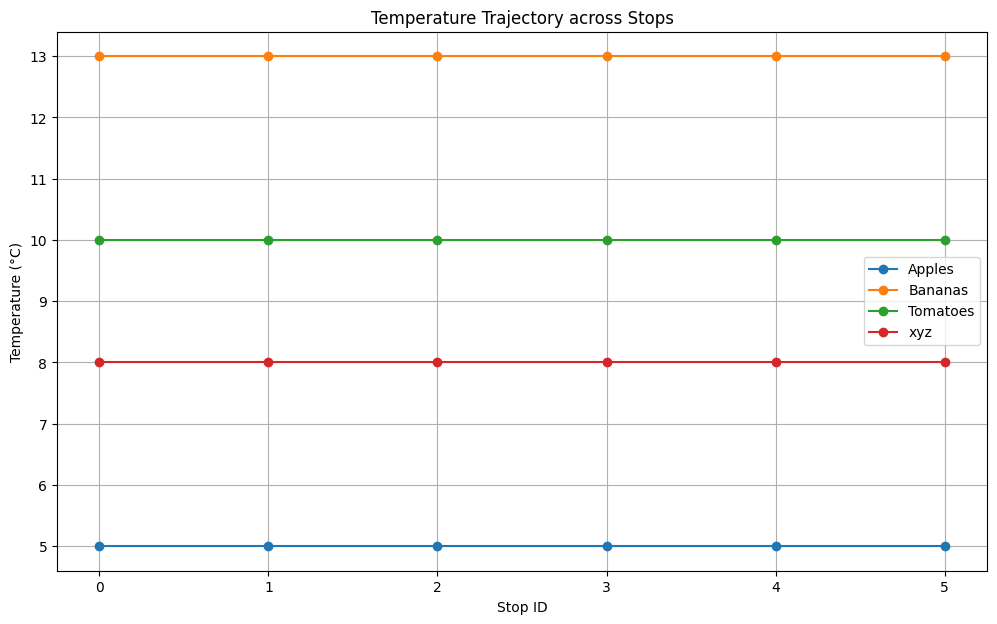

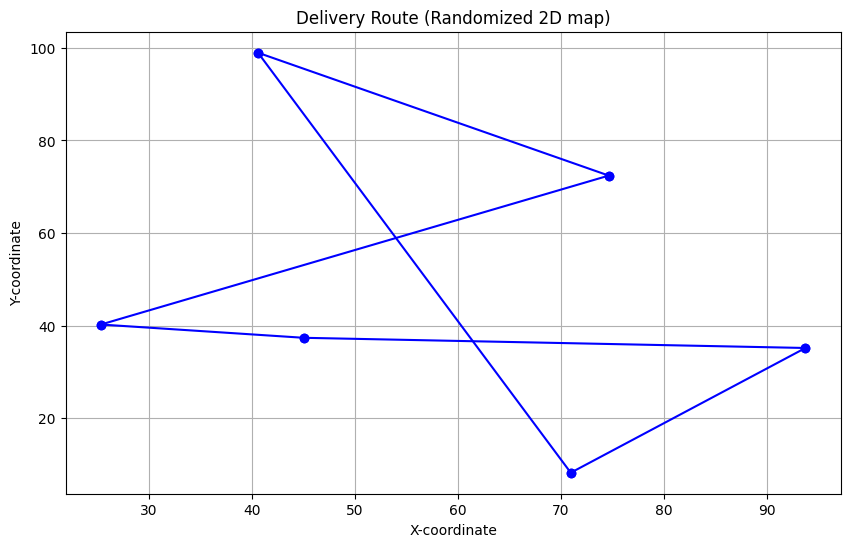

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from multiprocessing import Pool

# Set random seed for reproducibility
np.random.seed(6)

class PerishableTransportSensitivity:
    def __init__(self):
        # Initialize base model parameters
        self.n = 11  # Number of locations
        self.K = 4   # Number of products
        self.initialize_parameters()
        self.create_model()

    def initialize_parameters(self):
        """Initialize all model parameters"""
        # Base travel distances (km)
        self.base_travel_distance = {
            (0, 1): 55, (0, 2): 50, (0, 3): 45, (0, 4): 40, (0, 5): 35,
            (0, 6): 60, (0, 7): 65, (0, 8): 70, (0, 9): 75, (0, 10): 80,
            (1, 0): 55, (1, 2): 30, (1, 3): 40, (1, 4): 50, (1, 5): 60, (1, 6): 65,
            (1, 7): 70, (1, 8): 75, (1, 9): 80, (1, 10): 85,
            (2, 0): 50, (2, 1): 30, (2, 3): 35, (2, 4): 45, (2, 5): 55, (2, 6): 50,
            (2, 7): 55, (2, 8): 60, (2, 9): 65, (2, 10): 70,
            (3, 0): 45, (3, 1): 40, (3, 2): 35, (3, 4): 25, (3, 5): 30, (3, 6): 40,
            (3, 7): 45, (3, 8): 50, (3, 9): 55, (3, 10): 60,
            (4, 0): 40, (4, 1): 50, (4, 2): 45, (4, 3): 25, (4, 5): 20, (4, 6): 35,
            (4, 7): 40, (4, 8): 45, (4, 9): 50, (4, 10): 55,
            (5, 0): 35, (5, 1): 60, (5, 2): 55, (5, 3): 30, (5, 4): 20, (5, 6): 25,
            (5, 7): 30, (5, 8): 35, (5, 9): 40, (5, 10): 45,
            (6, 0): 60, (6, 1): 65, (6, 2): 50, (6, 3): 40, (6, 4): 35, (6, 5): 25,
            (6, 7): 20, (6, 8): 25, (6, 9): 30, (6, 10): 35,
            (7, 0): 65, (7, 1): 70, (7, 2): 55, (7, 3): 45, (7, 4): 40, (7, 5): 30,
            (7, 6): 20, (7, 8): 15, (7, 9): 20, (7, 10): 25,
            (8, 0): 70, (8, 1): 75, (8, 2): 60, (8, 3): 50, (8, 4): 45, (8, 5): 35,
            (8, 6): 25, (8, 7): 15, (8, 9): 10, (8, 10): 15,
            (9, 0): 75, (9, 1): 80, (9, 2): 65, (9, 3): 55, (9, 4): 50, (9, 5): 40,
            (9, 6): 30, (9, 7): 20, (9, 8): 10, (9, 10): 10,
            (10, 0): 80, (10, 1): 85, (10, 2): 70, (10, 3): 60, (10, 4): 55, (10, 5): 45,
            (10, 6): 35, (10, 7): 25, (10, 8): 15, (10, 9): 10,
        }

        self.base_travel_time = {k: v / 30 for k, v in self.base_travel_distance.items()}  # time in hours at 30 km/h

        self.travel_times = {(i, j): self.base_travel_time.get((i, j), 0) + np.random.uniform(-0.5, 0.5)
                            for i in range(self.n) for j in range(self.n) if i != j}

        self.delays = [np.random.uniform(0.1, 0.2) if np.random.rand() < 0.1 else 0 for _ in range(self.n)]

        # Temperature requirements
        self.required_temperature = [5, 13, 10, 8]  # Ideal temperatures (°C)
        self.initial_temperature = [5, 13, 10, 8]   # Starting at warehouse (°C)
        self.temperature_changes = np.random.uniform(-1, 1, (self.n, self.K))
        self.min_temp = [2, 10, 7, 5]  # Lower bound (°C)
        self.max_temp = [8, 16, 13, 11]  # Upper bound (°C)

        # Default model parameters
        self.beta = 0.2  # temperature correction factor
        self.temp_penalty_weight = 0.05
        self.slack_penalty_weight = 0.1
        self.M = 50  # Big-M value

    def create_model(self):
        """Create a fresh model instance"""
        model = gp.Model('Perishable_Transport_Sensitivity')

        # Decision Variables
        x = model.addVars(self.n, self.n, vtype=GRB.BINARY, name="x")
        u = model.addVars(self.n, lb=0, ub=self.n-1, vtype=GRB.CONTINUOUS)
        temp = model.addVars(self.n, self.K, vtype=GRB.CONTINUOUS, name="temp")
        abs_deviation = model.addVars(self.n, self.K, vtype=GRB.CONTINUOUS, name="abs_dev")
        slack = model.addVars(self.n, self.K, vtype=GRB.CONTINUOUS, name="slack")

        # Flow constraints
        model.addConstr(sum(x[0, j] for j in range(1, self.n)) == 1)
        model.addConstr(sum(x[i, 0] for i in range(1, self.n)) == 1)
        model.addConstrs((sum(x[i, j] for j in range(self.n) if j != i) == 1 for i in range(1, self.n)))
        model.addConstrs((sum(x[j, i] for j in range(self.n) if j != i) == 1 for i in range(1, self.n)))
        model.addConstrs((x[i, i] == 0 for i in range(self.n)))
        model.addConstrs((u[i] - u[j] + self.n * x[i, j] <= self.n-1
                         for i in range(1, self.n) for j in range(1, self.n) if i != j))

        # Temperature constraints
        for k in range(self.K):
            model.addConstr(temp[0, k] == self.initial_temperature[k])

        for i in range(self.n):
            for j in range(self.n):
                if i != j:
                    for k in range(self.K):
                        natural_shift = self.temperature_changes[j, k]
                        correction = self.beta * (self.required_temperature[k] - temp[i, k])

                        model.addConstr(
                            temp[j, k] >= temp[i, k] + natural_shift + correction -
                            slack[j, k] - self.M * (1 - x[i, j]))
                        model.addConstr(
                            temp[j, k] <= temp[i, k] + natural_shift + correction +
                            slack[j, k] + self.M * (1 - x[i, j]))

        # Temperature limits
        for j in range(self.n):
            for k in range(self.K):
                model.addConstr(temp[j, k] >= self.min_temp[k])
                model.addConstr(temp[j, k] <= self.max_temp[k])

        # Absolute deviation
        for j in range(self.n):
            for k in range(self.K):
                model.addConstr(abs_deviation[j, k] >= temp[j, k] - self.required_temperature[k])
                model.addConstr(abs_deviation[j, k] >= self.required_temperature[k] - temp[j, k])

        # Store references to variables we'll need
        model._x = x
        model._temp = temp
        model._abs_deviation = abs_deviation
        model._slack = slack

        return model

    def solve_model(self, model):
        """Solve the model and return performance metrics"""
        model.optimize()

        if model.status == GRB.OPTIMAL:
            total_hours = sum(
                (self.travel_times.get((i, j), 0) + self.delays[i]) * model._x[i, j].X
                for i in range(self.n) for j in range(self.n) if i != j
            )

            max_deviation = max(
                model._abs_deviation[j, k].X for j in range(self.n) for k in range(self.K)
            )

            avg_deviation = sum(
                model._abs_deviation[j, k].X for j in range(self.n) for k in range(self.K)
            ) / (self.n * self.K)

            return {
                'objective': model.objVal,
                'travel_time': total_hours,
                'max_deviation': max_deviation,
                'avg_deviation': avg_deviation,
                'status': 'optimal'
            }
        else:
            return {
                'objective': None,
                'travel_time': None,
                'max_deviation': None,
                'avg_deviation': None,
                'status': 'infeasible'
            }

    def evaluate_parameter_setting(self, param_name, param_value):
        """Evaluate a single parameter setting (for parallel execution)"""
        # Create a copy of the parameters
        local_params = copy.deepcopy(self.__dict__)

        # Update the specific parameter
        local_params[param_name] = param_value

        # Create a new instance with these parameters
        evaluator = PerishableTransportSensitivity()
        evaluator.__dict__.update(local_params)

        # Create and solve the model
        model = evaluator.create_model()

        # Update objective with current weights
        travel_cost = gp.quicksum(
            (evaluator.travel_times.get((i, j), 0) + evaluator.delays[i]) * model._x[i, j]
            for i in range(evaluator.n) for j in range(evaluator.n) if i != j
        )
        temperature_penalty = gp.quicksum(
            model._abs_deviation[j, k] for j in range(evaluator.n) for k in range(evaluator.K)
        )
        slack_penalty = gp.quicksum(
            model._slack[j, k] for j in range(evaluator.n) for k in range(evaluator.K)
        )

        model.setObjective(
            travel_cost + evaluator.temp_penalty_weight * temperature_penalty +
            evaluator.slack_penalty_weight * slack_penalty,
            GRB.MINIMIZE
        )

        # Solve and return results
        results = evaluator.solve_model(model)
        results.update({
            'parameter': param_name,
            'value': param_value
        })
        return results

def run_parallel_sensitivity(analysis, parameters):
    """Run parallel sensitivity analysis"""
    tasks = []
    for param_name, param_values in parameters.items():
        for value in param_values:
            tasks.append((param_name, value))

    with Pool() as pool:
        results = pool.starmap(analysis.evaluate_parameter_setting, tasks)

    return pd.DataFrame(results)

# Define parameter ranges for sensitivity analysis
sensitivity_params = {
    'beta': np.linspace(0.1, 0.5, 5),               # Fewer points for demo
    'temp_penalty_weight': np.linspace(0.01, 0.1, 5),
    'slack_penalty_weight': np.linspace(0.05, 0.2, 5),
}

# Run the sensitivity analysis
analysis = PerishableTransportSensitivity()
results_df = run_parallel_sensitivity(analysis, sensitivity_params)

# Save and visualize results
results_df.to_csv('sensitivity_results.csv', index=False)

# Visualization (same as before)
def visualize_results(df):
    sns.set_style("whitegrid")
    params = df['parameter'].unique()

    for param in params:
        param_df = df[df['parameter'] == param]

        plt.figure(figsize=(10, 6))
        plt.plot(param_df['value'], param_df['objective'], 'b-', label='Objective Value')
        plt.xlabel(param)
        plt.ylabel('Objective Function Value')
        plt.title(f'Sensitivity of Objective to {param}')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.plot(param_df['value'], param_df['max_deviation'], 'r-', label='Max Temp Deviation')
        plt.plot(param_df['value'], param_df['avg_deviation'], 'g--', label='Avg Temp Deviation')
        plt.xlabel(param)
        plt.ylabel('Temperature Deviation (°C)')
        plt.title(f'Sensitivity of Temperature Control to {param}')
        plt.legend()
        plt.grid(True)
        plt.show()

visualize_results(results_df)